In [1]:
# setup
import sys
import os

sys.path.append(os.path.abspath(".."))

# ICVul
import pandas as pd

from utils.stats import run_pct_stats

# Load the datasets
df_labels = pd.read_csv('../data/intermediate/commits_icvul.csv')
df_metrics = pd.read_csv('../data/intermediate/churn_icvul_semantic.csv')

# Merge the dataframes
df_vuln = pd.merge(
    df_labels.drop(columns=['commit_role'], errors='ignore'), 
    df_metrics, 
    on='commit_id',
    how='inner',
)

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

In [2]:
# KFC (Linux)
import pandas as pd

# Load the datasets
df_churn = pd.read_csv('../data/intermediate/churn_linux_semantic.csv')
df_labels = pd.read_csv('../data/intermediate/commits_dataset_linux.csv')

# Merge the datasets
# We drop 'commit_role' from df_churn so it doesn't conflict with df_labels
df_bug = pd.merge(
    df_labels, 
    df_churn.drop(columns=['commit_role'], errors='ignore'), 
    on='commit_id', 
    how='inner'
)

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

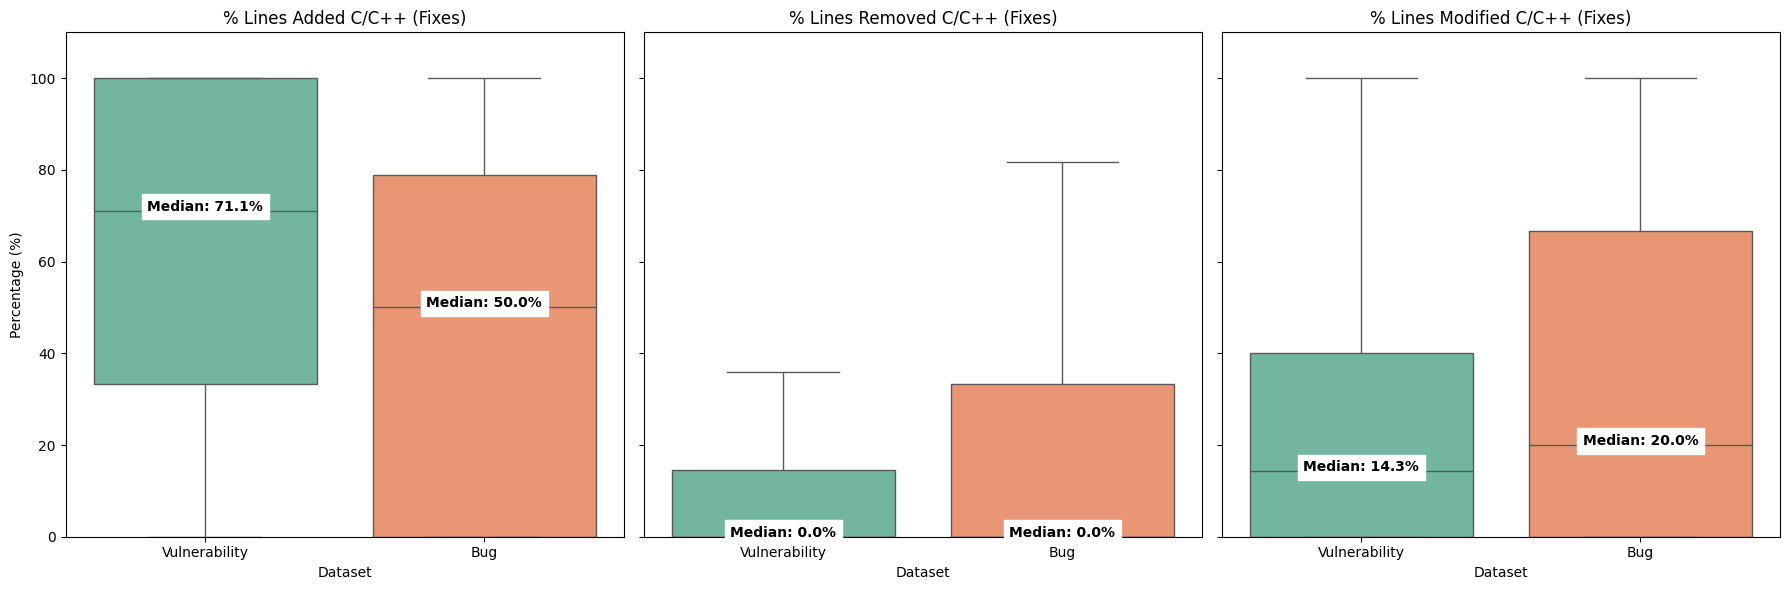


MANN-WHITNEY U TEST (% Metrics)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Pct Added          | 2.18e-12     |   0.233 (small     ) | *
Pct Removed        | 0.05482      |  -0.058 (negligible) | 
Pct Modified       | 0.00170      |  -0.103 (negligible) | *


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_fixing = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

df_fixing['total_delta'] = df_fixing['lines_added'] + df_fixing['lines_removed'] + df_fixing['lines_modified']

df_fixing = df_fixing[df_fixing['total_delta'] > 0].copy()

df_fixing['pct_added'] = (df_fixing['lines_added'] / df_fixing['total_delta']) * 100
df_fixing['pct_removed'] = (df_fixing['lines_removed'] / df_fixing['total_delta']) * 100
df_fixing['pct_modified'] = (df_fixing['lines_modified'] / df_fixing['total_delta']) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['pct_added', 'pct_removed', 'pct_modified']
titles = ['% Lines Added C/C++ (Fixes)', '% Lines Removed C/C++ (Fixes)', '% Lines Modified C/C++ (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_fixing, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels (Percentages)
    medians = df_fixing.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}%', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Percentage (%)' if i == 0 else '')
    ax.set_ylim(0, 110) # Percentages are 0-100

plt.tight_layout()
plt.show()
run_pct_stats(df_fixing)

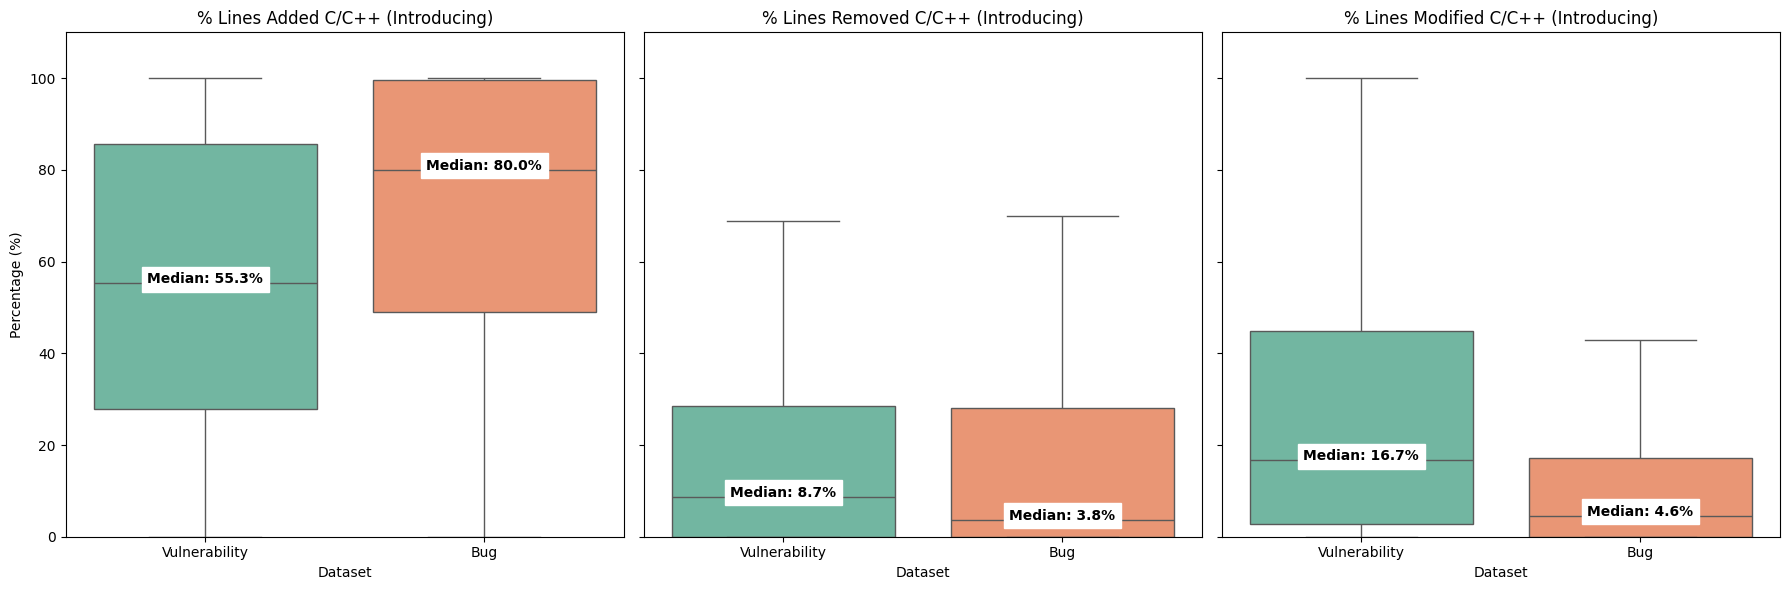


MANN-WHITNEY U TEST (% Metrics)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Pct Added          | 2.03e-26     |  -0.258 (small     ) | *
Pct Removed        | 0.00165      |   0.074 (negligible) | *
Pct Modified       | 2.24e-41     |   0.324 (small     ) | *


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

df_introducing = pd.concat([
    df_vuln[(df_vuln['commit_role'] == 'VIC') & (df_vuln['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[(df_bug['commit_role'] == 'BIC') & (df_bug['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

df_introducing['total_delta'] = df_introducing['lines_added'] + df_introducing['lines_removed'] + df_introducing['lines_modified']

df_introducing = df_introducing[df_introducing['total_delta'] > 0].copy()

df_introducing['pct_added'] = (df_introducing['lines_added'] / df_introducing['total_delta']) * 100
df_introducing['pct_removed'] = (df_introducing['lines_removed'] / df_introducing['total_delta']) * 100
df_introducing['pct_modified'] = (df_introducing['lines_modified'] / df_introducing['total_delta']) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['pct_added', 'pct_removed', 'pct_modified']
titles = ['% Lines Added C/C++ (Introducing)', '% Lines Removed C/C++ (Introducing)', '% Lines Modified C/C++ (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_introducing, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels (Percentages)
    medians = df_introducing.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}%', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Percentage (%)' if i == 0 else '')
    ax.set_ylim(0, 110) # Percentages are 0-100

plt.tight_layout()
plt.show()
run_pct_stats(df_introducing)

In [5]:
# TOSEM
import pandas as pd

# 1. Load the manual vulnerability dataset
df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem_semantic.csv')

# 2. Group by Type (VFC/VIC) and calculate stats
metrics = ['lines_added', 'lines_removed', 'lines_modified']
vuln_stats = df_vuln_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

In [6]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache_semantic.csv')

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

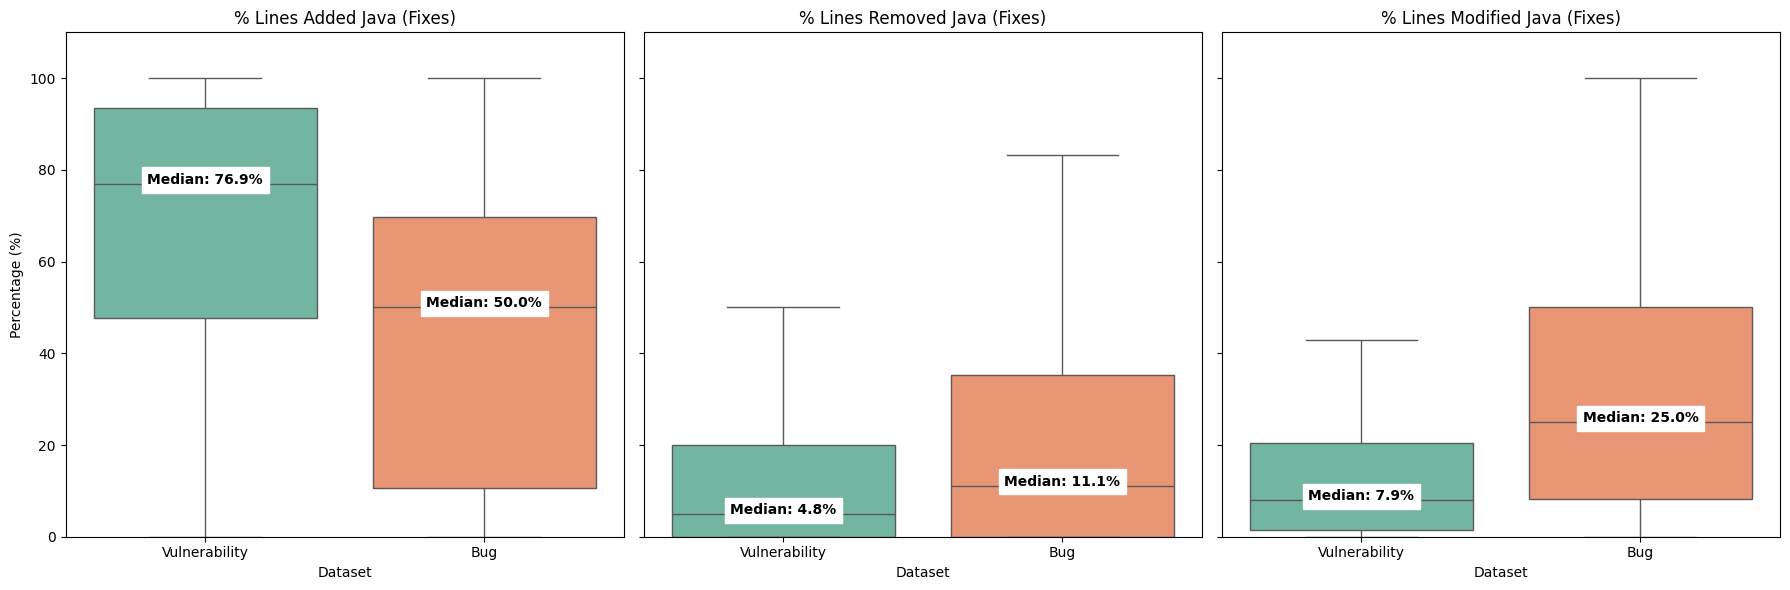


MANN-WHITNEY U TEST (% Metrics)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Pct Added          | 1.27e-11     |   0.404 (medium    ) | *
Pct Removed        | 0.03428      |  -0.124 (negligible) | 
Pct Modified       | 1.17e-08     |  -0.340 (medium    ) | *


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

df_java_comp['total_delta'] = df_java_comp['lines_added'] + df_java_comp['lines_removed'] + df_java_comp['lines_modified']

df_java_comp = df_java_comp[df_java_comp['total_delta'] > 0].copy()

df_java_comp['pct_added'] = (df_java_comp['lines_added'] / df_java_comp['total_delta']) * 100
df_java_comp['pct_removed'] = (df_java_comp['lines_removed'] / df_java_comp['total_delta']) * 100
df_java_comp['pct_modified'] = (df_java_comp['lines_modified'] / df_java_comp['total_delta']) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['pct_added', 'pct_removed', 'pct_modified']
titles = ['% Lines Added Java (Fixes)', '% Lines Removed Java (Fixes)', '% Lines Modified Java (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels (Percentages)
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}%', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Percentage (%)' if i == 0 else '')
    ax.set_ylim(0, 110) # Percentages are 0-100

plt.tight_layout()
plt.show()
run_pct_stats(df_java_comp)

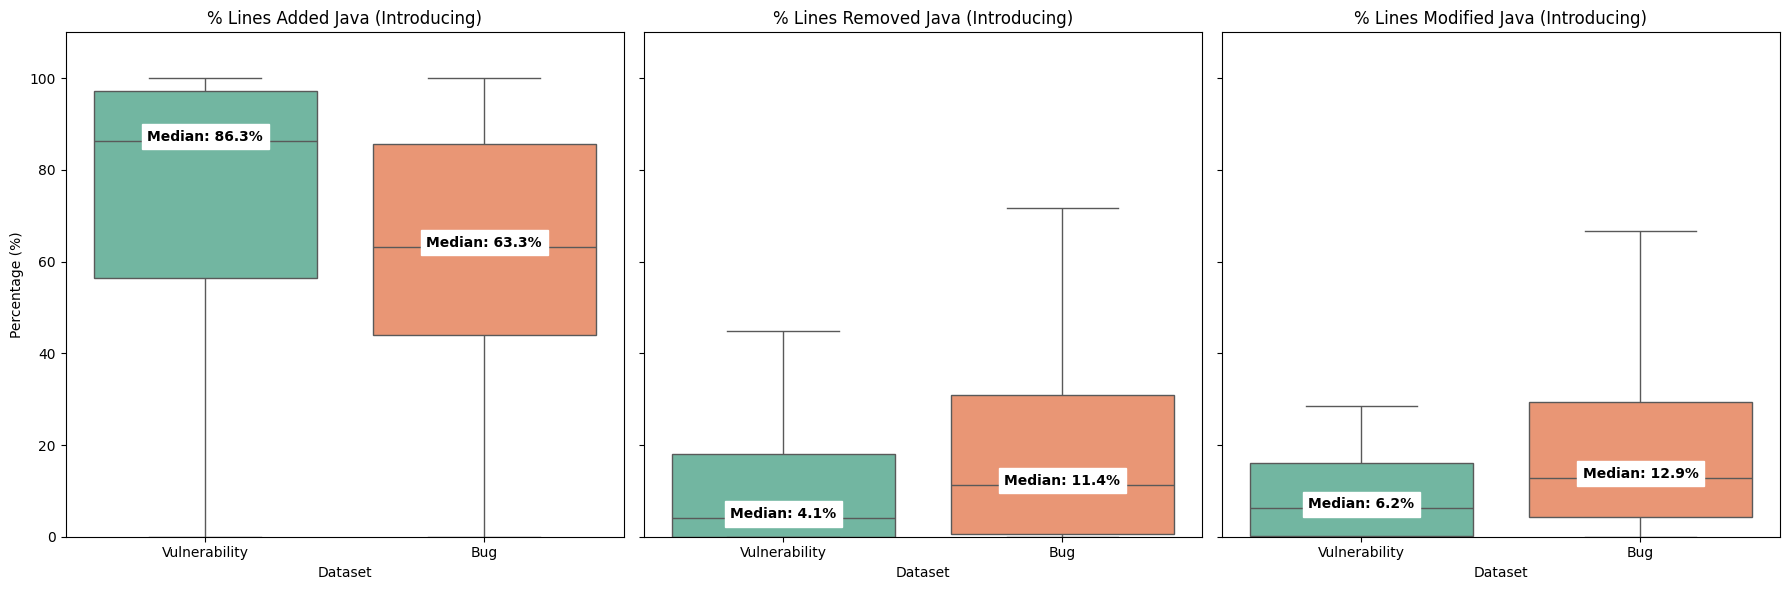


MANN-WHITNEY U TEST (% Metrics)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Pct Added          | 1.19e-05     |   0.316 (small     ) | *
Pct Removed        | 0.01383      |  -0.176 (small     ) | *
Pct Modified       | 6.54e-05     |  -0.288 (small     ) | *


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixses
df_v = df_java_vic_only.copy()
df_v = df_v[df_v['lines_added'] < 10000]
df_b = df_java_bic_only.copy()
df_b = df_b[df_b['lines_added'] < 10000] # this dataset doesn't have any commits with > 10k

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp_i = pd.concat([df_v, df_b])

df_java_comp_i['total_delta'] = df_java_comp_i['lines_added'] + df_java_comp_i['lines_removed'] + df_java_comp_i['lines_modified']

df_java_comp_i = df_java_comp_i[df_java_comp_i['total_delta'] > 0].copy()

df_java_comp_i['pct_added'] = (df_java_comp_i['lines_added'] / df_java_comp_i['total_delta']) * 100
df_java_comp_i['pct_removed'] = (df_java_comp_i['lines_removed'] / df_java_comp_i['total_delta']) * 100
df_java_comp_i['pct_modified'] = (df_java_comp_i['lines_modified'] / df_java_comp_i['total_delta']) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['pct_added', 'pct_removed', 'pct_modified']
titles = ['% Lines Added Java (Introducing)', '% Lines Removed Java (Introducing)', '% Lines Modified Java (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp_i, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels (Percentages)
    medians = df_java_comp_i.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}%', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Percentage (%)' if i == 0 else '')
    ax.set_ylim(0, 110) # Percentages are 0-100

plt.tight_layout()
plt.show()
run_pct_stats(df_java_comp_i)